# Financial Sentiment Analysis: Trading Performance vs. Fear & Greed Index

Let analyzes the relationship between market sentiment (Fear & Greed Index) and actual trading performance (PnL, Win Rate).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df1=pd.read_csv('fear_greed_index.csv')
df2=pd.read_csv('historical_data.csv')

In [ ]:
df1.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [ ]:
df2.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [ ]:
df1.shape,df2.shape

((2644, 4), (211224, 16))

In [ ]:
df1.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [ ]:
df2.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [ ]:
df1.isnull().sum()


,0
timestamp,0
value,0
classification,0
date,0


In [ ]:
df2.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [ ]:
df1['date']=pd.to_datetime(df1['date'])
df2['date']=pd.to_datetime(df2['Timestamp IST'],dayfirst=True).dt.date
df1['date']=df1['date'].dt.date

In [ ]:
df1.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [ ]:
df2.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


In [ ]:
merged=pd.merge(df2,df1,on='date',how='inner')
merged.shape

(211218, 20)

In [ ]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed


# Basic Cleaning


In [ ]:
merged.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,timestamp,value
count,211218.000000,2.112180e+05,2.112180e+05,2.112180e+05,211218.000000,2.112180e+05,211218.000000,2.112180e+05,2.112180e+05,2.112180e+05,211218.000000
mean,11415.047529,4.623341e+03,5.639192e+03,-2.994671e+04,48.549304,6.965470e+10,1.163960,5.628506e+14,1.737745e+12,1.738301e+09,51.649656
std,29448.010305,1.042744e+05,3.657557e+04,6.738170e+05,917.989791,1.835714e+10,6.758948,3.257541e+14,8.689946e+09,8.029302e+06,21.012784
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,1.682919e+09,10.000000
25%,4.858550,2.940000e+00,1.937900e+02,-3.760725e+02,0.000000,5.984223e+10,0.016121,2.810000e+14,1.740000e+12,1.735623e+09,33.000000
50%,18.280000,3.200000e+01,5.970200e+02,8.477051e+01,0.000000,7.442939e+10,0.089572,5.620000e+14,1.740000e+12,1.740375e+09,49.000000
75%,101.895000,1.878900e+02,2.058878e+03,9.337697e+03,5.790132,8.335543e+10,0.393774,8.460000e+14,1.740000e+12,1.743572e+09,72.000000
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12,1.746077e+09,94.000000


In [ ]:
merged.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [ ]:
merged.duplicated().sum()

np.int64(0)

In [ ]:
merged.columns=(merged.columns.str.strip().str.lower().str.replace(' ','_'))
merged.columns

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp', 'date', 'timestamp', 'value', 'classification'],
      dtype='object')

In [ ]:
merged.head()

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed


In [ ]:
for i , c in enumerate(merged.columns):
  print(i,c)

0 account
1 coin
2 execution_price
3 size_tokens
4 size_usd
5 side
6 timestamp_ist
7 start_position
8 direction
9 closed_pnl
10 transaction_hash
11 order_id
12 crossed
13 fee
14 trade_id
15 timestamp
16 date
17 timestamp
18 value
19 classification


In [ ]:
cols=list(merged.columns)
cols[15]='trade_timestamp'
cols[17]='sentiment_timestamp'
merged.columns=cols

In [ ]:
merged.columns

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'trade_timestamp', 'date', 'sentiment_timestamp', 'value',
       'classification'],
      dtype='object')

In [ ]:
(merged['closed_pnl']==0).sum()

np.int64(106816)

In [ ]:
merged['closed_pnl'].describe()

,closed_pnl
count,211218.000000
mean,48.549304
std,917.989791
min,-117990.104100
25%,0.000000
50%,0.000000
75%,5.790132
max,135329.090100


In [ ]:
merged['closed_pnl'].quantile([0.01,0.05,0.95,0.99])

,closed_pnl
0.01,-140.779546
0.05,-5.321168
0.95,165.601637
0.99,1022.630947


In [ ]:
merged['classification'].value_counts(dropna=False)

,count
classification,
Fear,61837
Greed,50303
Extreme Greed,39992
Neutral,37686
Extreme Fear,21400


#EDA

In [ ]:
#Risk -adjusted view
merged.groupby('classification')['closed_pnl'].agg(['mean','median','std','count'])
#high mean and high std mean risky profits

,mean,median,std,count
classification,,,,
Extreme Fear,34.537862,0.0,1136.056091,21400
Extreme Greed,67.892861,0.0,766.828294,39992
Fear,54.290400,0.0,935.355438,61837
Greed,42.743559,0.0,1116.028390,50303
Neutral,34.307718,0.0,517.122220,37686


In [ ]:
#Win rate by sentiment
merged['win']=merged['closed_pnl']>0
merged.groupby('classification')['win'].mean()*100 #how often the traders actually win in each market emotion

,win
classification,
Extreme Fear,37.060748
Extreme Greed,46.494299
Fear,42.076750
Greed,38.482794
Neutral,39.699093


In [ ]:
#Zero-trade behaviour
(merged['closed_pnl']==0).groupby(merged['classification']).mean()*100

,closed_pnl
classification,
Extreme Fear,51.373832
Extreme Greed,47.857071
Fear,51.795850
Greed,49.951295
Neutral,51.814998


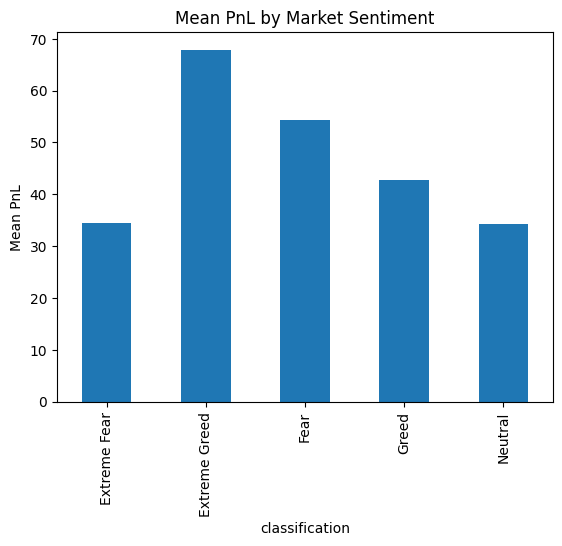

In [ ]:
merged.groupby('classification')['closed_pnl'].mean().plot(kind='bar')
plt.title('Mean PnL by Market Sentiment')
plt.ylabel('Mean PnL')
plt.show()

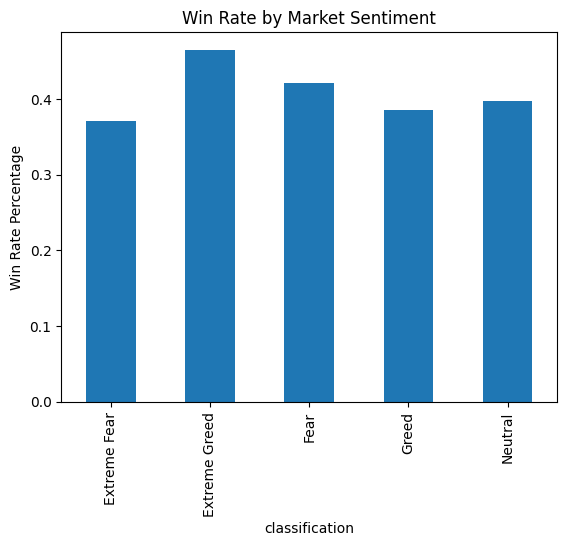

In [ ]:
merged.groupby('classification')['win'].mean().plot(kind='bar')
plt.title('Win Rate by Market Sentiment')
plt.ylabel('Win Rate Percentage')
plt.show()

In [ ]:
merged[['value','closed_pnl']].corr()

,value,closed_pnl
value,1.000000,0.008121
closed_pnl,0.008121,1.000000


### Distribution of Profits across Sentiments
Let's visualize the density of trade outcomes to understand the risk profile better.

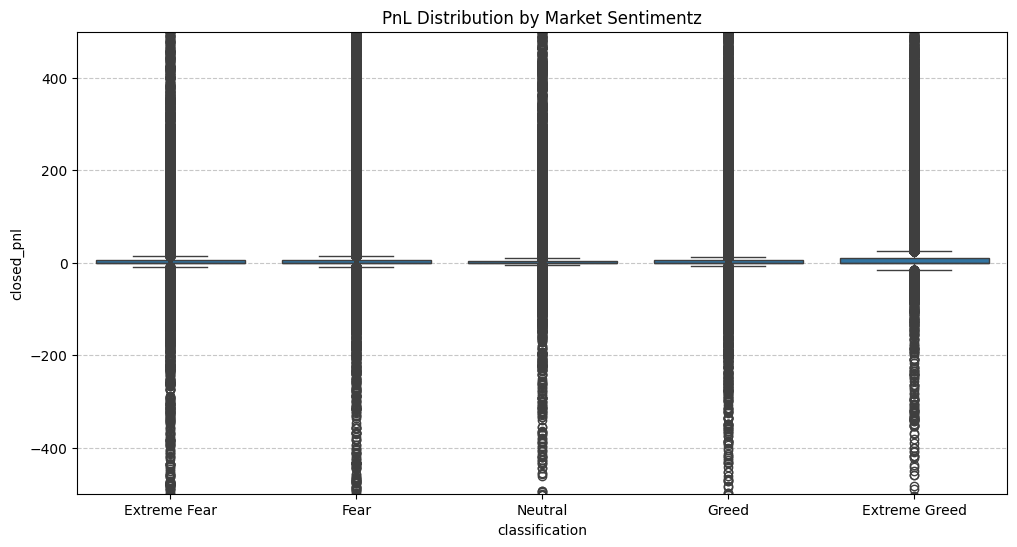

In [ ]:
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.boxplot(x='classification', y='closed_pnl', data=merged, order=['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])
plt.ylim(-500, 500) # Zooming in to see the bulk of the distribution
plt.title('PnL Distribution by Market Sentimentz')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
#average trade sized in the market sentiment
merged.groupby('classification')['size_usd'].mean()


,size_usd
classification,
Extreme Fear,5349.731843
Extreme Greed,3112.251565
Fear,7816.109931
Greed,5736.884375
Neutral,4782.732661


In [ ]:
#in which sentiment traders do agressive treding
merged.groupby('classification')['fee'].mean()


,fee
classification,
Extreme Fear,1.116291
Extreme Greed,0.675902
Fear,1.495172
Greed,1.254372
Neutral,1.044798


In [ ]:
merged[['fee','closed_pnl']].corr()

,fee,closed_pnl
fee,1.000000,0.084094
closed_pnl,0.084094,1.000000


### Fee vs. Profitability Correlation
Visualizing if higher fees (often associated with larger trades) lead to better outcomes.

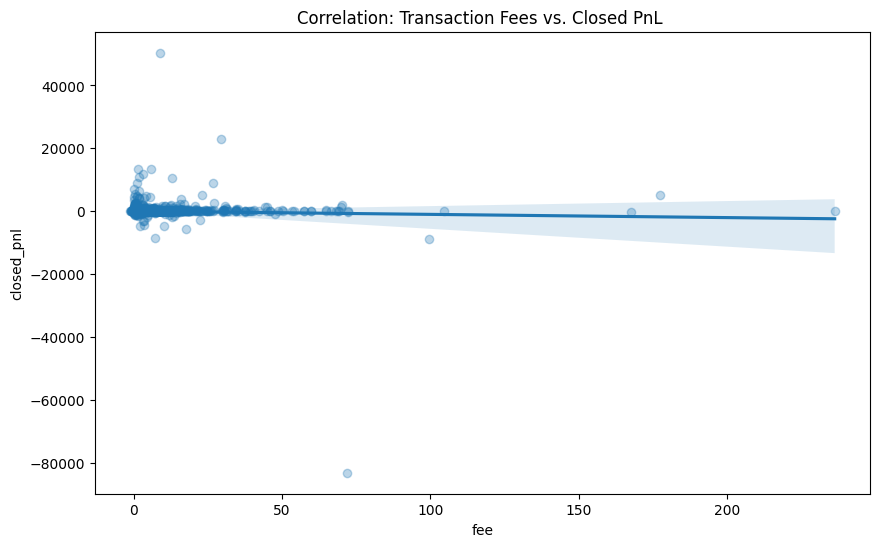

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='fee', y='closed_pnl', data=merged.sample(10000), scatter_kws={'alpha':0.3})
plt.title('Correlation: Transaction Fees vs. Closed PnL ')
plt.show()

Frequent vs Infrequent

In [ ]:
trades_per_trader=merged['account'].value_counts()
thresold=trades_per_trader.median()
merged['freq_segment']=merged['account'].map(
    lambda x:'Frequent' if trades_per_trader[x]>=thresold else "Infrequent"
)
merged.groupby('freq_segment')['closed_pnl'].agg(['mean','median','std','count'])

,mean,median,std,count
freq_segment,,,,
Frequent,42.493421,0.0,892.157938,186957
Infrequent,95.216371,0.0,1095.729988,24261


In [ ]:
#fro above --> "Higher activity may reduce efficiency"

In [ ]:
merged.groupby('freq_segment')['win'].mean()*100

,win
freq_segment,
Frequent,41.543777
Infrequent,37.896212


Big vs Small position traders

In [ ]:
size_cut=merged['size_usd'].median()
merged['size_segment']=merged['size_usd'].apply(
    lambda x:'Large' if x>size_cut else 'Small'
)
merged.groupby('size_segment')['closed_pnl'].agg(['mean','median','std','count'])

,mean,median,std,count
size_segment,,,,
Large,92.719310,0.0,1296.323370,105607
Small,4.380971,0.0,33.077922,105611


In [ ]:
merged.groupby('size_segment')['win'].mean()*100

,win
size_segment,
Large,41.533232
Small,40.716403


Consistent winners

In [ ]:

merged['side'].value_counts()
pd.crosstab(merged['classification'],merged['side'],normalize='index')*100

side,BUY,SELL
classification,,
Extreme Fear,51.098131,48.901869
Extreme Greed,44.858972,55.141028
Fear,48.951275,51.048725
Greed,48.855933,51.144067
Neutral,50.334342,49.665658


#MODELS

***Classification***

In [ ]:
model_df=merged.copy()
model_df.head()


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,...,fee,trade_id,trade_timestamp,date,sentiment_timestamp,value,classification,win,freq_segment,size_segment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed,False,Infrequent,Large
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed,False,Infrequent,Small
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed,False,Infrequent,Large
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed,False,Infrequent,Large
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed,False,Infrequent,Small


In [ ]:
model_df['pnl_bucket']=pd.qcut(
    model_df['closed_pnl'],
    q=3,
    labels=['Low','Medium','High']
)
model_df[['pnl_bucket','closed_pnl']]

,pnl_bucket,closed_pnl
0,Low,0.0000
1,Low,0.0000
2,Low,0.0000
3,Low,0.0000
4,Low,0.0000
...,...,...
211213,Low,-20.2566
211214,Low,-112.5773
211215,Low,-22.4402
211216,Low,-190.7894


In [ ]:
model_df['pnl_bucket'].value_counts()

,count
pnl_bucket,
Low,124355
High,70406
Medium,16457


In [ ]:
features=model_df.loc[:,[
    'size_usd',
    'fee',
    'win'
]]

In [ ]:
sentiment_map = {
    'Extreme Fear': 0,
    'Fear': 1,
    'Neutral': 2,
    'Greed': 3,
    'Extreme Greed': 4
}
model_df['sentiment_encoded']=model_df['classification'].map(sentiment_map)


In [ ]:
features['sentiment']=model_df['sentiment_encoded']
features

,size_usd,fee,win,sentiment
0,7872.16,0.345404,False,4
1,127.68,0.005600,False,4
2,1150.63,0.050431,False,4
3,1142.04,0.050043,False,4
4,69.75,0.003055,False,4
...,...,...,...,...
211213,420.80,0.042080,False,3
211214,2338.63,0.233863,False,3
211215,466.16,0.046616,False,3
211216,3963.38,0.396337,False,3


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report


In [ ]:
X=features
y=model_df['pnl_bucket']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

clf=RandomForestClassifier(n_estimators=30,random_state=42)
clf.fit(X_train,y_train)

pred=clf.predict(X_test)
print('Accuracy_score:',accuracy_score(y_test,pred))
print(classification_report(y_test,pred))

Accuracy_score: 0.9569406306221002
              precision    recall  f1-score   support

        High       0.93      0.94      0.94     14115
         Low       1.00      1.00      1.00     24848
      Medium       0.73      0.70      0.72      3281

    accuracy                           0.96     42244
   macro avg       0.89      0.88      0.88     42244
weighted avg       0.96      0.96      0.96     42244



In [ ]:
#because the model is bias towards the low class
#we use the SMOTE (synthetic minority oversampling technique)
from imblearn.over_sampling import SMOTE


In [ ]:
X=features
y=model_df['pnl_bucket']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

smote=SMOTE(random_state=42)
X_train_res,y_train_res=smote.fit_resample(X_train,y_train)


In [ ]:
clf = RandomForestClassifier(
    n_estimators=30,
    random_state=42
)

clf.fit(X_train_res, y_train_res)

RandomForestClassifier(n_estimators=30, random_state=42)

In [ ]:
y_pred=clf.predict(X_test)
print("Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.9524429504781744
              precision    recall  f1-score   support

        High       0.94      0.92      0.93     14081
         Low       1.00      1.00      1.00     24871
      Medium       0.68      0.74      0.71      3292

    accuracy                           0.95     42244
   macro avg       0.87      0.89      0.88     42244
weighted avg       0.95      0.95      0.95     42244



In [ ]:
'''After applying SMOTE to handle class imbalance,
 the model became more balanced across classes.
 While overall accuracy slightly decreased,
 the recall for the minority 'Medium' class improved,
 indicating better generalization rather than majority-class bias.
 This trade-off is expected and desirable in imbalanced classification problems.'''

## clustering

In [ ]:
cluster_feature=model_df.loc[:,[
    'size_usd',
    'fee',
    'win',
    'sentiment_encoded'
]]

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaled_data=scaler.fit_transform(cluster_feature)


In [ ]:
from sklearn.cluster import KMeans
Kmeans=KMeans(n_clusters=3,random_state=42)
model_df['cluster']=Kmeans.fit_predict(scaled_data)

In [ ]:
model_df['cluster'].value_counts()

,count
cluster,
1,123974
0,86551
2,693


In [ ]:
model_df.groupby('cluster')[['size_usd','win','fee']].mean().round()

,size_usd,win,fee
cluster,,,
0,4213.30,1.00,0.92
1,4378.68,0.00,0.91
2,409222.67,0.45,78.40


#INSIGHTS

## Insight 1: Market sentiment affects trader efficiency more than it strongly predicts profitability.

Extreme Greed showed the highest win rate (46.5%) despite smaller average position sizes and the lowest average fees, suggesting traders may perform better through more efficient execution rather than larger risk-taking during this sentiment regime.

Fear showed larger average position sizes and higher fees, indicating more aggressive but costlier trading behavior.

At the same time, the correlation between sentiment value and closed PnL was extremely weak (~0.008), implying sentiment alone is not a strong direct predictor of profitability.

## Insight 2: Frequent and infrequent traders show a consistency versus payoff tradeoff.

Frequent traders had a higher win rate (41.5%) but lower average PnL (~42), suggesting more consistent but smaller gains.

Infrequent traders had a lower win rate (37.9%) but much higher average PnL (~95), suggesting profitability may come from fewer, higher-conviction trades with larger payoffs.

This indicates trading frequency may affect not just consistency, but the structure of profitability itself.

## Insight 3: Position size appears to affect payoff magnitude more than win probability.

Large position traders generated much higher average PnL (~92.7 vs ~4.4 for small positions), while win rates were nearly identical (41.5% vs 40.7%).

This suggests higher profitability from large positions is driven more by larger winning payoffs than by winning more often.

This points to a risk-return tradeoff, where larger positions increase upside, but likely with higher volatility.

## Summary

This analysis finds that market sentiment alone is not a strong direct predictor of trader profitability, but it does appear to influence trading behavior and execution efficiency.

Extreme Greed showed the highest win rate, while Fear was associated with larger position sizes and higher fees, suggesting different sentiment regimes may shape how traders take risk.

Trader segmentation showed that infrequent traders achieved higher average PnL despite lower win rates, while large position traders generated higher profitability mainly through larger payoffs rather than higher win probability.

Overall, the findings suggest trader behavior, position sizing, and execution efficiency may matter more for performance than sentiment alone.